In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
from sympy import symbols, simplify, diff, integrate, exp, solve, sqrt, oo
from spb import plot3d_parametric_surface, PB, plot

In [4]:
import warnings
warnings.filterwarnings("ignore")

# Exponential Distribution

In [5]:
from scipy.stats import expon

## Introduction

The **exponential distribution** is a continuous probability distribution used to model the time until an event occurs or the time between independent events occurring at a constant average rate.

## Examples

The exponential distribution is frequently used to provide probabilistic answers to questions such as:
- How much time will elapse before an earthquake occurs in a given region?
- How long do we need to wait until a customer enters our shop?
- How long will it take before a call center receives the next phone call?
- How long will a piece of machinery work without breaking down?

All these questions concern the time we need to wait before a given event occurs.

If this waiting time is unknown, it is often appropriate to think of it as a random variable having an exponential distribution.

## Distribution

In [ ]:
# define x and y as symbolic variables
x, y, lamb = symbols('x y lambda', real=True, positive=True)

In [17]:
scaleValue=2 # scale=1/lambda)

### Probability Density Function (`.pdf`)

The probability density function (**pdf**) of the **exponential distribution** is
$$
f(x, \lambda) = 
\begin{cases}
\lambda e^{-\lambda x} & x \geq 0, \\
0                      & x < 0.
\end{cases}
$$

In [8]:
# create an algebraic expression
pdf = lamb*exp(-lamb*x)
pdf

lambda*exp(-lambda*x)

In [16]:
expon.pdf(5, scale=scaleValue)

np.float64(0.0410424993119494)

### Cumulative Distribution Function (`.cdf`)

In [10]:
# Compute the indefinite integral of the expression f with respect to x
cdf = integrate(pdf, (x, 0, y))
print(cdf)

1 - exp(-lamb*y)


Suppose that the time in days until hospital discharge for a certain patient population
follows a density $f(x)=\frac{1}{10}\exp(−x/10)$ for $x>0$.
Calculate the probability that a person takes longer than 11 days to be discharged. 
Express it as an integer percentage with no digits after the decimal.

In [18]:
1-(1 - exp(-11/10))

0.332871083698079

In [14]:
expon.cdf(11, scale=scaleValue)

np.float64(0.6671289163019205)

### Quantiles (`.ppf`)

In [21]:
cdf

1 - exp(-lamb*y)

In [22]:
p0 = symbols('p0', real=True)
ppf = simplify(solve(cdf-p0, y)[0])
print(ppf)

log(-1/(p0 - 1))/lamb


Suppose that the time in days until hospital discharge for a certain patient population follows a density $f(x)=\frac{1}{2}\exp(−x/2)$ for $x>0$.  
What is the median discharge time in days?

In [20]:
ppf = expon.ppf(0.5, scale=2)
print(f"P(X<={ppf} | λ={scaleValue}) = {0.5}")

P(X<=1.3862943611198906 | λ=2) = 0.5


In [53]:
cdf_value = 0.7
ppf = expon.ppf(cdf_value, scale=scaleValue)
print(f"P(X<={ppf} | λ={scaleValue}) = {cdf_value}")

P(X<=6.0198640216296795 | λ=5) = 0.7


In [43]:
cdf_value = 0.25
ppf = expon.ppf(cdf_value, scale=5)
print(f"P(X<={ppf} | λ={5}) = {cdf_value}")

P(X<=1.4384103622589044 | λ=5) = 0.25


### Mean or expected value (`.mean`)

In [10]:
pdf

lambda*exp(-lambda*x)

In [14]:
simplify(integrate(pdf*x, (x,0, y)))

(-lambda*y + exp(lambda*y) - 1)*exp(-lambda*y)/lambda

In [15]:
# Compute the mean integral of the expression fx with respect to x
mean = simplify(integrate(pdf*x, (x, 0, oo)))
print(mean)

1/lambda


In [18]:
expon.mean(scale=scaleValue)

np.float64(2.0)

### Variances (`.var`) and Standard Deviation (`.std`)

In [56]:
var = simplify(integrate(pdf*(x-mean)**2, (x, 0, oo)))
print(var)

lamb**(-2)


In [58]:
expon.var(scale=scaleValue)

np.float64(25.0)

In [60]:
std = simplify(sqrt(var))
print(std)

1/lamb


In [59]:
expon.std(scale=scaleValue)

np.float64(5.0)

## Visualization

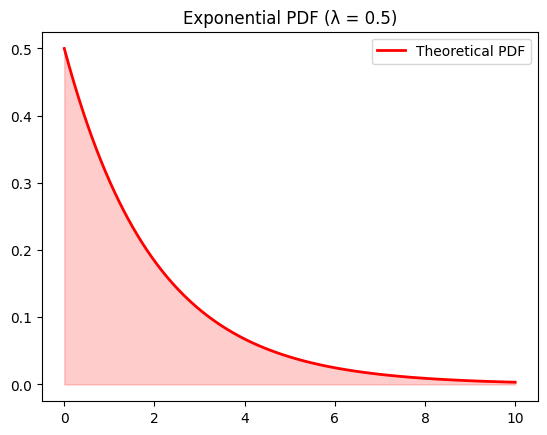

In [6]:
# Define parameters (scale = 1/lambda)
scale_val = 2.0
x = np.linspace(0, 10, 100)
y = expon.pdf(x, scale=scale_val)

plt.plot(x, y, 'r-', lw=2, label='Theoretical PDF')
plt.fill_between(x, y, color='red', alpha=0.2)
plt.title(f"Exponential PDF (λ = {1/scale_val})")
plt.legend()
plt.show()

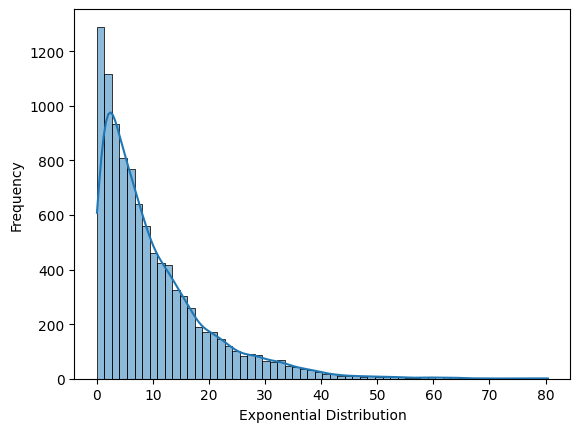

In [26]:
#creating the exponential distribution
data = expon.rvs(loc=0,scale=10,size=10000)
#plotting the  data
ax = sns.histplot(data,
                  bins=60,
                  kde=True,
                  # color='red'
                )
ax.set(xlabel='Exponential Distribution', ylabel='Frequency')

plt.show()

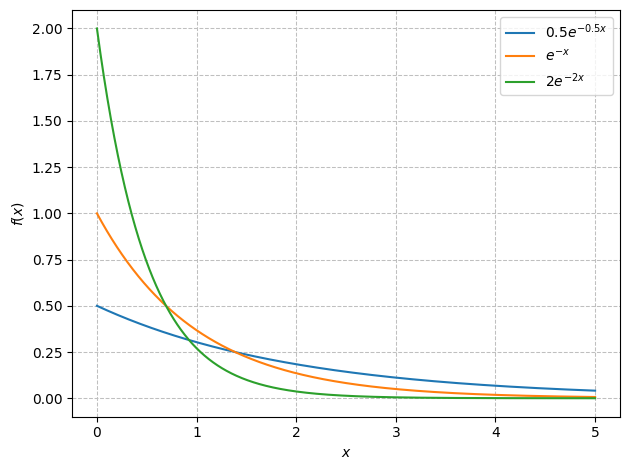

In [40]:
p = plot(0.5*exp(-0.5*x), 1*exp(-1*x), 2*exp(-2*x), (x, 0, 5),
    legend=True,
    labels=['$\frac{e^{-x/2}}{2}$', '$e^{-x}$', '$2e^{-2x}$'],
    show=False, 
)
# plt.legend()
p.show()

## References

- [Exponential distribution](https://en.wikipedia.org/wiki/Exponential_distribution)
- [4.2.2 Exponential Distribution](https://www.probabilitycourse.com/chapter4/4_2_2_exponential.php) 
- [SymPy: A Complete Guide to Symbolic Mathematics in Python](https://www.datacamp.com/tutorial/sympy)
- [Exponential distribution by Marco Taboga, PhD](https://www.statlect.com/probability-distributions/exponential-distribution)
- [Understanding the Exponential Distribution: A Comprehensive Guide](https://www.datacamp.com/tutorial/exponential-distribution)